In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

df = pd.read_csv('../data/cleaned/df_main.csv')
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp'], errors='coerce')
os.makedirs('../reports', exist_ok=True)
print(f"Loaded: {df.shape}")
print("Setup complete")

Loaded: (110197, 28)
Setup complete


In [2]:
# Step 1: Build RFM table
# Reference date = day after last order
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

# Use customer_unique_id for true customer identity
# (customer_id changes per order on Olist)
rfm = df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp',
             lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('price', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)
print(f"\nRFM table shape: {rfm.shape}")
print("\nRFM Summary Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

Snapshot date: 2018-08-30

RFM table shape: (93358, 4)

RFM Summary Statistics:
        Recency  Frequency  Monetary
count  93358.00   93358.00  93358.00
mean     237.94       1.03    141.62
std      152.59       0.21    215.69
min        1.00       1.00      0.85
25%      114.00       1.00     47.65
50%      219.00       1.00     89.73
75%      346.00       1.00    154.74
max      714.00      15.00  13440.00


Mean Recency (238 days) + Mean Frequency (1.03 orders) combined finding:
The average Olist customer is a one-time buyer who purchased 8 months ago and never returned. This is a customer ACQUISITION platform, not a customer RETENTION platform. The core business challenge is not winning customers back — it's converting 
first-time buyers into second-time buyers.
The Max Monetary column and max recency columns are creating a small doubt ,  are those orders or the value coming from one customer(using for bussiness likely) or different customers? 

In [ ]:
# Check if the max-monetary and max-frequency customers overlap
top_monetary = rfm.nlargest(10, 'Monetary')[['customer_unique_id','Monetary','Frequency','Recency']]
top_frequency = rfm.nlargest(10, 'Frequency')[['customer_unique_id','Frequency','Monetary','Recency']]

print("Top 10 by Monetary:")
print(top_monetary)
print("\nTop 10 by Frequency:")
print(top_frequency)

# Check overlap
top_m_ids = set(top_monetary['customer_unique_id'])
top_f_ids = set(top_frequency['customer_unique_id'])
overlap = top_m_ids.intersection(top_f_ids)
print(f"\nCustomers in BOTH top-10 lists: {len(overlap)}")
print(overlap)

Top 10 by Monetary:
                     customer_unique_id  Monetary  Frequency  Recency
3724   0a0a92112bd4c708ca5fde585afaa872   13440.0          1      334
79636  da122df9eeddfedc1dc1f5349a1a690c    7388.0          2      515
43168  763c8b1c9c68a0229c42c9fc6f662b93    7160.0          1       46
80463  dc4802a71eae9be1dd28f5d788ceb526    6735.0          1      563
25436  459bef486812aa25204be022145caa62    6729.0          1       35
93081  ff4159b92c40ebe40454e3e6a7c35ed6    6499.0          1      462
23411  4007669dec559734d6f53e029e360987    5934.6          1      279
87148  eebb5dda148d3893cdaf5b5ca3040ccb    4690.0          1      498
26640  48e1ac109decbb87765a3eade6854098    4590.0          1       69
59163  a229eba70ec1c2abef51f04987deb7a5    4400.0          1       90

Top 10 by Frequency:
                     customer_unique_id  Frequency  Monetary  Recency
51431  8d50f5eadf50201ccdcedfb9e2ac8455         15    714.63        9
22779  3e43e6105506432c953e165fb2acf44c         

: 

In [3]:
# Step 2: Score each customer 1-5 on R, F, M
# R: lower recency = better (bought recently) → reverse score
# F: higher frequency = better
# M: higher monetary = better

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5,
                          labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + \
                   rfm['F_Score'].astype(str) + \
                   rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("RFM Scores assigned")
print(rfm[['customer_unique_id','Recency','Frequency',
           'Monetary','R_Score','F_Score','M_Score','RFM_Score']].head(10))

RFM Scores assigned
                 customer_unique_id  Recency  Frequency  Monetary  R_Score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    129.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     18.90        4   
2  0000f46a3911fa3c0805444483337064      537          1     69.00        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     25.99        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    180.00        2   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    154.00        4   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     27.99        4   
7  00053a61a98854899e70ed204dd4bafe      183          1    382.00        3   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    135.00        1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    104.90        4   

   F_Score  M_Score RFM_Score  
0        1        4       414  
1        1        1       411  
2        1        2      

## Finding — Two Completely Different Types of "Valuable" Customers

High Monetary customers (top spenders):
→ Almost universally one-time buyers
→ Bought one expensive item (appliance, furniture, electronics)
→ High Recency (200-500+ days ago) — likely never returning
→ These are "big ticket, one-shot" buyers

High Frequency customers (most orders):
→ Low total spend despite many orders
→ Buying cheap items repeatedly (avg ₹47/order for top buyer)
→ Low Recency (9 days for the #1 most frequent buyer) — still active
→ These are "habit buyers" — small purchases, consistent engagement

Business Implication:
A customer who spent ₹13,440 once is NOT automatically your best customer. A customer who placed 15 orders totalling ₹714 might actually be more valuable long-term — they're still active,
they have a habit, and there's room to increase their basket size.

This is exactly why RFM combines all three dimensions rather than 
ranking customers on any single metric.

In [4]:
# Step 3: Assign customer segments based on RFM scores
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    elif r >= 4 and f == 1 and m >= 3:
        return 'Promising'
    else:
        return 'Need Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('customer_unique_id','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean'),
    Total_Revenue=('Monetary','sum')
).round(2).reset_index()
segment_summary = segment_summary.sort_values('Total_Revenue', ascending=False)

print("\n" + "="*60)
print("CUSTOMER SEGMENT SUMMARY")
print("="*60)
print(segment_summary.to_string(index=False))


CUSTOMER SEGMENT SUMMARY
            Segment  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue
     Need Attention           28899       307.74           1.01        100.45     2902833.08
            At Risk           13192       393.48           1.07        214.61     2831108.85
    Loyal Customers           14159       154.29           1.05        180.37     2553837.02
   Recent Customers           14984        90.88           1.00        139.31     2087427.21
          Champions            6517        91.46           1.17        274.03     1785868.12
Potential Loyalists            9344       160.67           1.01         86.57      808908.78
               Lost            6263       396.91           1.00         40.16      251515.05


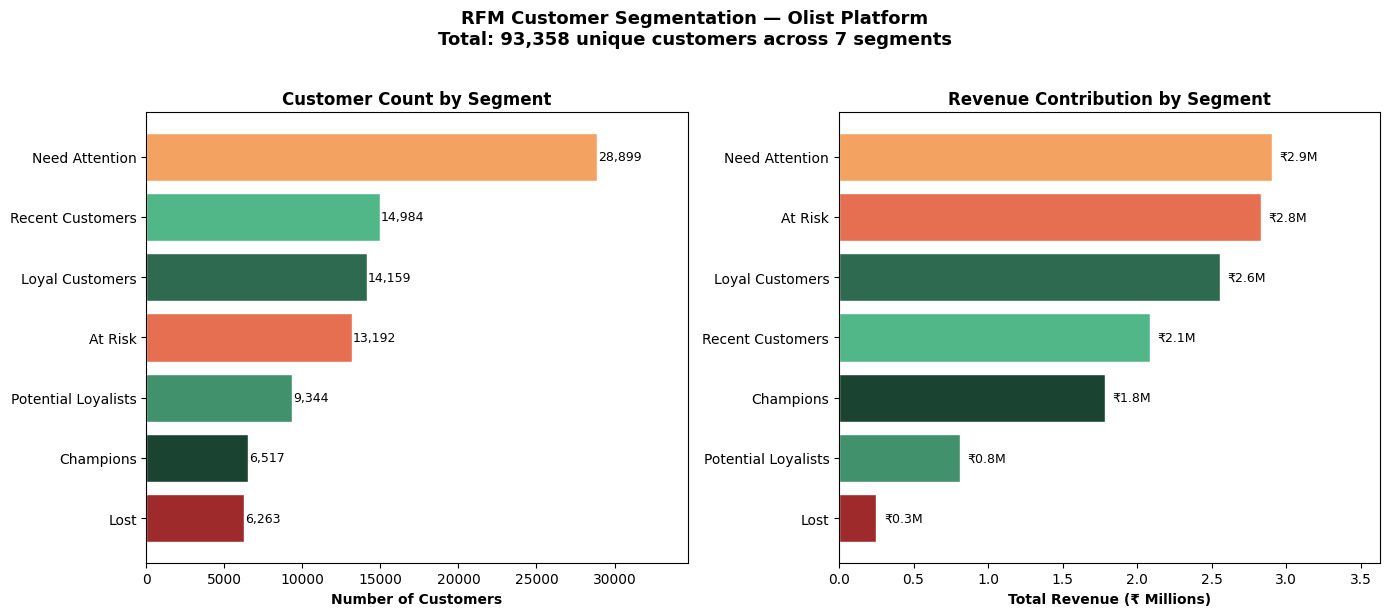

RFM chart saved


In [5]:
# Step 4: Visualise segments
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Chart A: Customer count per segment
colors_seg = {
    'Champions': '#1B4332',
    'Loyal Customers': '#2D6A4F',
    'Potential Loyalists': '#40916C',
    'Recent Customers': '#52B788',
    'Promising': '#74C69D',
    'Need Attention': '#F4A261',
    'At Risk': '#E76F51',
    'Cannot Lose Them': '#E24B4A',
    'Lost': '#9E2A2B'
}
seg_plot = segment_summary.sort_values('Customer_Count', ascending=True)
bar_colors = [colors_seg.get(s, '#95D5B2') for s in seg_plot['Segment']]
axes[0].barh(seg_plot['Segment'], seg_plot['Customer_Count'],
             color=bar_colors, edgecolor='white', linewidth=1)
for i, (_, row) in enumerate(seg_plot.iterrows()):
    axes[0].text(row['Customer_Count'] + 50, i,
                 f"{row['Customer_Count']:,}", va='center', fontsize=9)
axes[0].set_xlabel('Number of Customers', fontsize=10, fontweight='bold')
axes[0].set_title('Customer Count by Segment', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, seg_plot['Customer_Count'].max() * 1.2)

# Chart B: Revenue per segment
seg_rev = segment_summary.sort_values('Total_Revenue', ascending=True)
rev_colors = [colors_seg.get(s, '#95D5B2') for s in seg_rev['Segment']]
axes[1].barh(seg_rev['Segment'], seg_rev['Total_Revenue']/1e6,
             color=rev_colors, edgecolor='white', linewidth=1)
for i, (_, row) in enumerate(seg_rev.iterrows()):
    axes[1].text(row['Total_Revenue']/1e6 + 0.05, i,
                 f"₹{row['Total_Revenue']/1e6:.1f}M", va='center', fontsize=9)
axes[1].set_xlabel('Total Revenue (₹ Millions)', fontsize=10, fontweight='bold')
axes[1].set_title('Revenue Contribution by Segment', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, seg_rev['Total_Revenue'].max()/1e6 * 1.25)

plt.suptitle('RFM Customer Segmentation — Olist Platform\n'
             f'Total: {rfm.shape[0]:,} unique customers across {len(rfm["Segment"].unique())} segments',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/chart5_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("RFM chart saved")

In [6]:
# Step 5: Business personas for each segment
personas = {
    'Champions': 'Bought recently, buy often, spend the most. Reward them. Ask for reviews. Early-adopters for new products.',
    'Loyal Customers': 'Regular buyers with solid spend. Offer loyalty programs. Strong candidates for upselling.',
    'Potential Loyalists': 'Recent customers with average frequency. Nurture with targeted offers to convert to Loyal.',
    'Recent Customers': 'Bought recently but infrequent. Need engagement — personalised follow-up emails.',
    'Promising': 'Recent buyers, high spend, low frequency. High potential — engage before they go cold.',
    'Need Attention': 'Above-average RFM but not recent. Risk of losing. Send re-engagement campaign now.',
    'At Risk': 'Used to buy often and spend well — now going quiet. Urgent win-back campaign needed.',
    'Cannot Lose Them': 'Highest-value customers going silent. Immediate personal outreach required.',
    'Lost': 'Bought long ago, rarely, cheap. Very low re-activation probability. Low priority.'
}

print("\n" + "="*60)
print("SEGMENT PERSONAS & RECOMMENDED ACTIONS")
print("="*60)
for seg, persona in personas.items():
    count = rfm[rfm['Segment']==seg].shape[0]
    rev = rfm[rfm['Segment']==seg]['Monetary'].sum()
    print(f"\n{seg} ({count:,} customers | ₹{rev:,.0f} total revenue)")
    print(f"  → {persona}")


SEGMENT PERSONAS & RECOMMENDED ACTIONS

Champions (6,517 customers | ₹1,785,868 total revenue)
  → Bought recently, buy often, spend the most. Reward them. Ask for reviews. Early-adopters for new products.

Loyal Customers (14,159 customers | ₹2,553,837 total revenue)
  → Regular buyers with solid spend. Offer loyalty programs. Strong candidates for upselling.

Potential Loyalists (9,344 customers | ₹808,909 total revenue)
  → Recent customers with average frequency. Nurture with targeted offers to convert to Loyal.

Recent Customers (14,984 customers | ₹2,087,427 total revenue)
  → Bought recently but infrequent. Need engagement — personalised follow-up emails.

Promising (0 customers | ₹0 total revenue)
  → Recent buyers, high spend, low frequency. High potential — engage before they go cold.

Need Attention (28,899 customers | ₹2,902,833 total revenue)
  → Above-average RFM but not recent. Risk of losing. Send re-engagement campaign now.

At Risk (13,192 customers | ₹2,831,109 tota

In [9]:
# Check if the max-monetary and max-frequency customers overlap
top_monetary = rfm.nlargest(10, 'Monetary')[['customer_unique_id','Monetary','Frequency','Recency']]
top_frequency = rfm.nlargest(10, 'Frequency')[['customer_unique_id','Frequency','Monetary','Recency']]

print("Top 10 by Monetary:")
print(top_monetary)
print("\nTop 10 by Frequency:")
print(top_frequency)

# Check overlap
top_m_ids = set(top_monetary['customer_unique_id'])
top_f_ids = set(top_frequency['customer_unique_id'])
overlap = top_m_ids.intersection(top_f_ids)
print(f"\nCustomers in BOTH top-10 lists: {len(overlap)}")
print(overlap)

Top 10 by Monetary:
                     customer_unique_id  Monetary  Frequency  Recency
3724   0a0a92112bd4c708ca5fde585afaa872   13440.0          1      334
79636  da122df9eeddfedc1dc1f5349a1a690c    7388.0          2      515
43168  763c8b1c9c68a0229c42c9fc6f662b93    7160.0          1       46
80463  dc4802a71eae9be1dd28f5d788ceb526    6735.0          1      563
25436  459bef486812aa25204be022145caa62    6729.0          1       35
93081  ff4159b92c40ebe40454e3e6a7c35ed6    6499.0          1      462
23411  4007669dec559734d6f53e029e360987    5934.6          1      279
87148  eebb5dda148d3893cdaf5b5ca3040ccb    4690.0          1      498
26640  48e1ac109decbb87765a3eade6854098    4590.0          1       69
59163  a229eba70ec1c2abef51f04987deb7a5    4400.0          1       90

Top 10 by Frequency:
                     customer_unique_id  Frequency  Monetary  Recency
51431  8d50f5eadf50201ccdcedfb9e2ac8455         15    714.63        9
22779  3e43e6105506432c953e165fb2acf44c         

In [8]:
# Save RFM results to reports
segment_summary.to_csv('../reports/rfm_segment_summary.csv', index=False)
rfm[['customer_unique_id','Recency','Frequency','Monetary',
     'R_Score','F_Score','M_Score','RFM_Score','Segment']].to_csv(
    '../reports/rfm_customer_scores.csv', index=False)
print("RFM tables saved to reports")

RFM tables saved to reports
